In [ ]:
"""
Jupiter notebook for testing rd encoder
Written with help of Claude.ai
"""

'\nJupiter notebook for testing rd encoder\n'

In [ ]:
import sys

import pandas as pd
import numpy as np
import os
from matplotlib import pyplot as plt
from PIL import Image
# Supprimer le module du cache
if 'rd_encoder' in sys.modules:
    del sys.modules['rd_encoder']

# Import frais
from encoder import rd_encoder
from encoder import ra_encoder

In [2]:
from dataset import RADIal

config = {
    "dataset":{
        "root_dir": "/Benson_DATA3/Public/RADIal/ready_to_use/RADIal/",
        "geometry":{
            "ranges": [512,256,1],
            "resolution": [0.201171875,0.1],
            "size": 3
        },
    },
    "data_mode": "Custom_RD"
    
}
statistics = {  "input_mean":np.zeros(32),
                "input_std":np.ones(32),
                "reg_mean":np.zeros(3),
                "reg_std":np.ones(3)}

enc = rd_encoder(geometry = config['dataset']['geometry'],
                        statistics = statistics,
                        regression_layer = 2)

dataset = RADIal(root_dir = config['dataset']['root_dir'],
                        statistics= statistics,
                        encoder=enc.encode,
                        difficult=True,perform_FFT=config['data_mode'])

radar_FFT, segmap,out_label,box_labels,image = dataset.__getitem__(0)



Range: 169.18, Doppler: 16.00
Range: 55.57, Doppler: 236.00
Range: 110.14, Doppler: 16.00
Range: 36.71, Doppler: 16.00


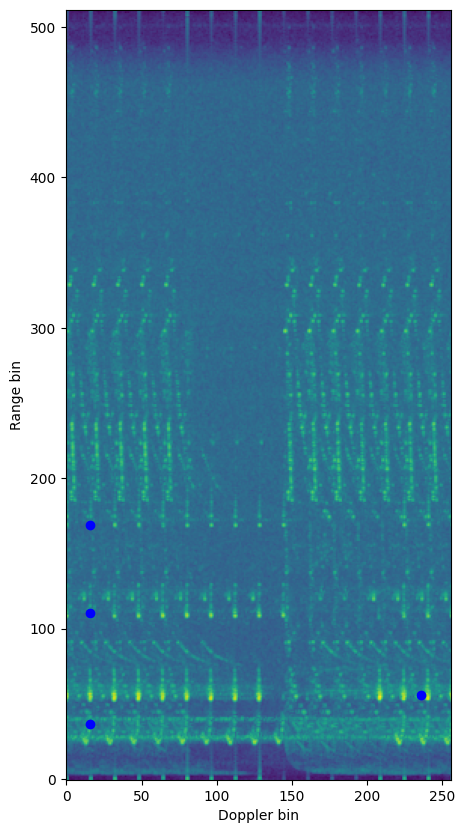

In [3]:
radar_FFT = radar_FFT[...,::2]+1j*radar_FFT[...,1::2]
power_spectrum = np.sum(np.abs(radar_FFT),axis=2)

fig, ax = plt.subplots(figsize=(10, 10))
ax.imshow(np.log10(power_spectrum), origin='lower')

for box in box_labels:
    if(box[0]==-1):
        break # -1 means no object
    Range = box[0] * 512/103 # 512 range bins for 103m
    Doppler = box[2]
    print(f"Range: {Range:.2f}, Doppler: {Doppler:.2f}")
    
    ax.plot(Doppler, Range, 'bo')
ax.set_xlabel('Doppler bin')
ax.set_ylabel('Range bin')
plt.show()

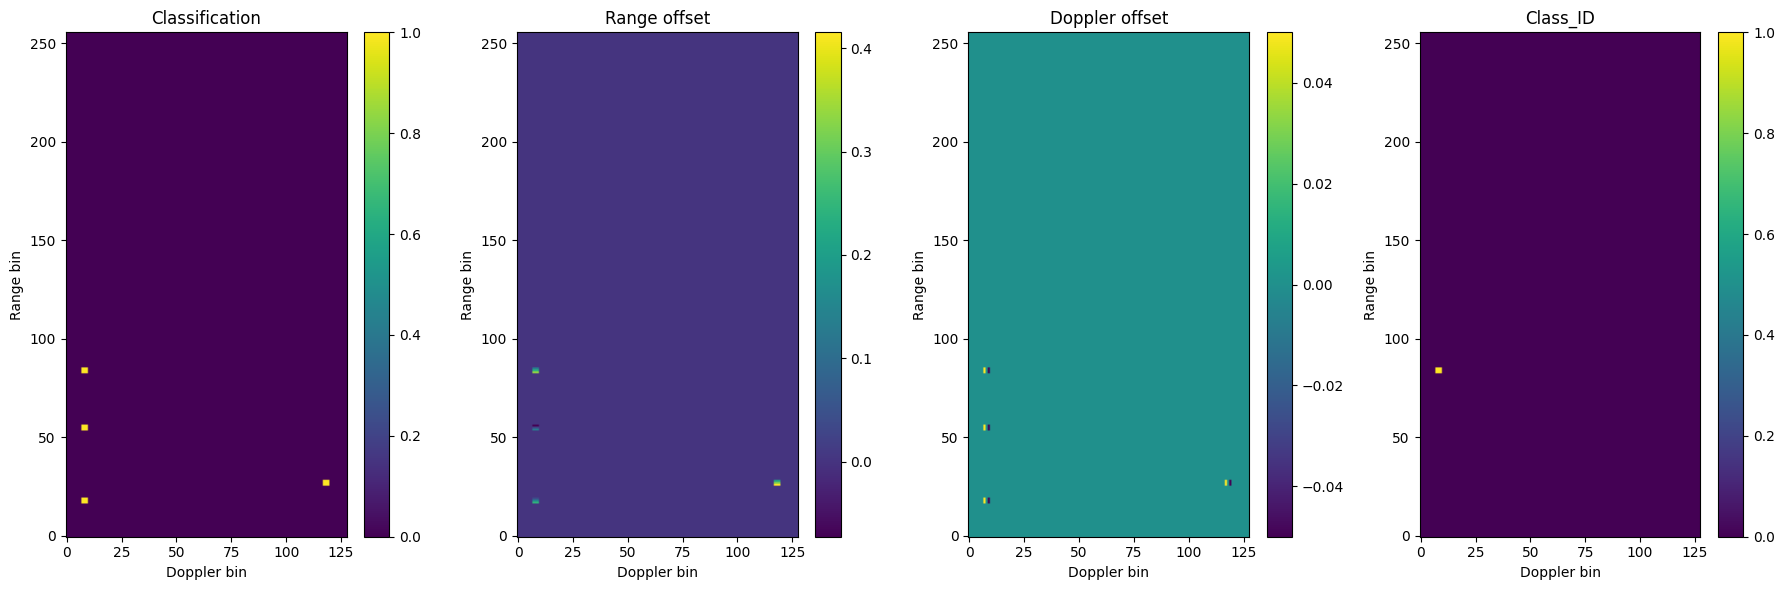

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

titles = ['Classification', 'Range offset', 'Doppler offset', "Class_ID"]
for i, (ax, title) in enumerate(zip(axes, titles)):
    im = ax.imshow(out_label[i], origin='lower', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Doppler bin')
    ax.set_ylabel('Range bin')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()


In [5]:
decoded = enc.decode(out_label, threshold=0.05)

print(f"{len(decoded)} detections decoded:\n")
print(f"{'Range (m)':>12}  {'Doppler (m/s)':>14}  {'Score':>8}  {'Class':>8}")
print("-" * 50)
for R, D, C, CLS in decoded:
    print(f"{R:>12.2f}  {D:>14.2f}  {C:>8.3f}  {int(CLS):>8}")

36 detections decoded:

   Range (m)   Doppler (m/s)     Score     Class
--------------------------------------------------
        7.08          -11.35     1.000         0
        7.08          -11.20     1.000         0
        7.08          -11.05     1.000         0
        7.39          -11.35     1.000         0
        7.39          -11.20     1.000         0
        7.39          -11.05     1.000         0
        7.69          -11.35     1.000         0
        7.69          -11.20     1.000         0
        7.69          -11.05     1.000         0
       10.88           10.65     1.000         0
       10.88           10.80     1.000         0
       10.88           10.95     1.000         0
       11.18           10.65     1.000         0
       11.18           10.80     1.000         0
       11.18           10.95     1.000         0
       11.48           10.65     1.000         0
       11.48           10.80     1.000         0
       11.48           10.95     1.000     

In [6]:
geometry= {
            "ranges": [512,896,1],
            "resolution": [0.201171875,0.2],
            "size": 1
        }
statistics = {
    "reg_mean":[0.4048094369863972,0.3997392847799934],
    "reg_std":[0.6968599580482511,0.6942950877813826]
}
encoder = ra_encoder(geometry, statistics, regression_layer=2)  

encoded_map = encoder.encode(box_labels)
print(f"\nEncoded map shape: {encoded_map.shape}")
print(f"  Channel 0 (classification): {np.sum(encoded_map[0] > 0)} detections")
print(f"  Channel 1 (range offset): min={encoded_map[1].min():.3f}, max={encoded_map[1].max():.3f}")
print(f"  Channel 2 (doppler offset): min={encoded_map[2].min():.3f}, max={encoded_map[2].max():.3f}")


Encoded map shape: (4, 128, 224)
  Channel 0 (classification): 4 detections
  Channel 1 (range offset): min=-0.375, max=0.448
  Channel 2 (doppler offset): min=-0.576, max=0.432


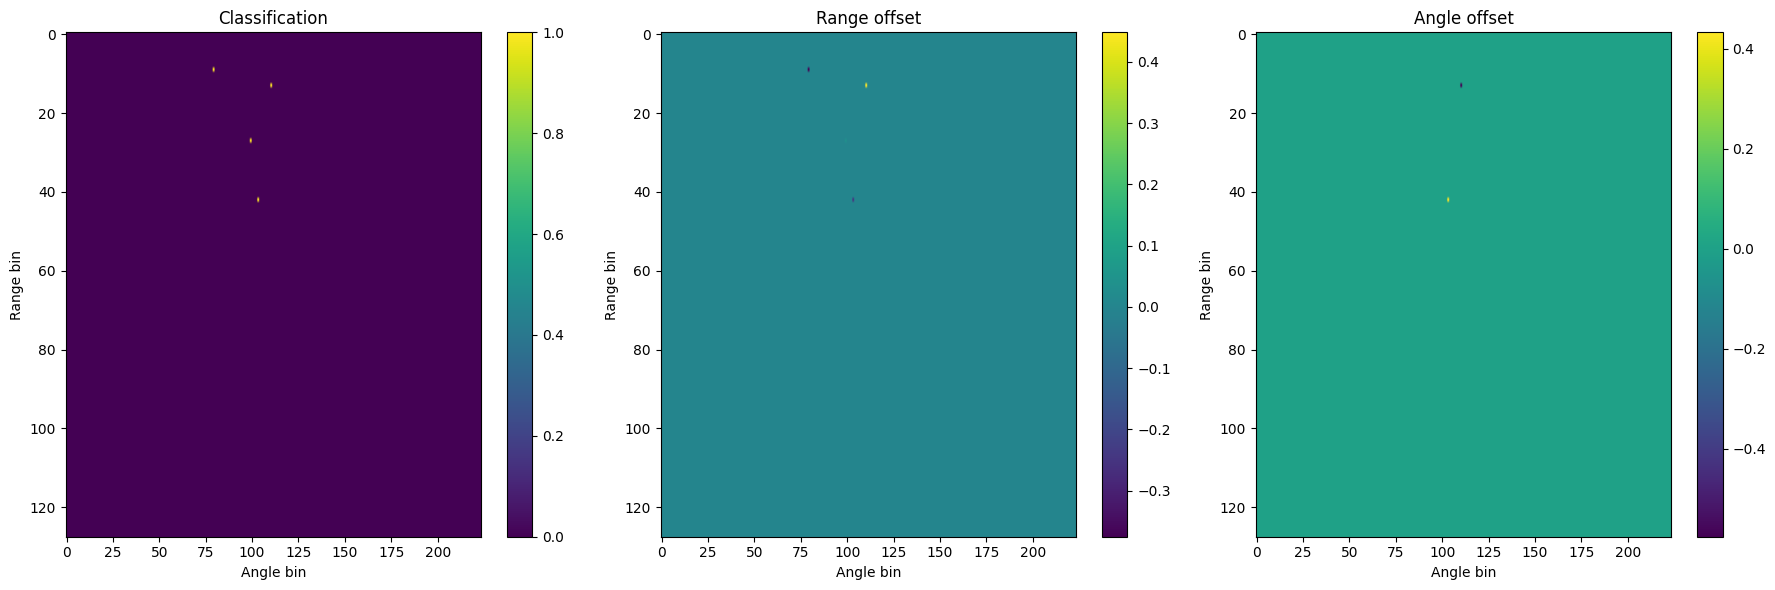

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titles = ['Classification', 'Range offset', 'Angle offset']
for i, (ax, title) in enumerate(zip(axes, titles)):
    im = ax.imshow(encoded_map[i], origin='upper', aspect='auto')
    ax.set_title(title)
    ax.set_xlabel('Angle bin')
    ax.set_ylabel('Range bin')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

In [8]:
decoded = encoder.decode(encoded_map, threshold=0.05)

print(f"{len(decoded)} detections decoded:\n")
print(f"{'Range (m)':>12}  {'Angle (bin)':>14}  {'Score':>8}")
print("-" * 40)
for R, D, C in decoded:
    print(f"{R:>12.2f}  {D:>14.2f}  {C:>8.3f}")

4 detections decoded:

   Range (m)     Angle (bin)     Score
----------------------------------------


ValueError: too many values to unpack (expected 3)